# Многоклассовая классификация через многослойную искусственную нейронную сеть

## Цель:

1. Создать многослойную искусственную нейронную сеть (ИНС) для решения задачи идентификации успевающих в учебе студентов. Исходный набор данных math_students.csv прилагается.

2. Разбить набор данных на обучающий (70%) и тестовый (30%).

3. Обучить ИНС на обучающем наборе данных. Оценить погрешность ИНС на обучающем наборе данных и на тестовом наборе данных: вычислить точность, чувствительность и специфичность.

4. Проанализировать работу ИНС и, изменив параметры ИНС или проведя дополнительную обработку набора данных, добиться уменьшения погрешности  ИНС на тестовом наборе данных. Посчитать также погрешность ИНС на обучающем наборе данных.

## Признаки датасета:

- **school** Школа студента (бинарный: 'GP' - Габриэль Перейра или 'MS' - Мусинью де Силвейра)
- **sex:** Пол студента (бинарный: 'F' - женский или 'M' - мужской)
- **age:** Возраст студента (числовой: от 15 до 22)
- **address:** Тип домашнего адреса студента (бинарный: 'U' - городской или 'R' - сельский)
- **famsize:** Размер семьи (бинарный: 'LE3' - меньше или равно 3 или 'GT3' - больше 3)
- **Pstatus:** Статус сожительства родителей (бинарный: 'T' - живут вместе или 'A' - раздельно)
- **Medu:** Образование матери (числовой: 0 - отсутствует, 1 - начальное образование (4-й класс), 2 – с 5 по 9 класс, 3 – среднее образование или 4 – высшее образование)
- **Fedu:** Образование отца (числовой: 0 - отсутствует, 1 - начальное образование (4-й класс), 2 – с 5 по 9 класс, 3 – среднее образование или 4 – высшее образование)
- **Mjob:** Профессия матери (номинальный: 'учитель', связанный с 'здравоохранением', 'государственные' службы (например, административные или полицейские), 'дома' или 'другое')
- **Fjob:** Профессия отца (номинальный: 'учитель', связанный с 'здравоохранением', 'государственные' службы (например, административные или полицейские), 'дома' или 'другое')
- **reason:** Причина выбора этой школы (номинальный: 'близко к 'дому', 'репутация' школы, 'предпочтение' курса или 'другое')
- **guardian:** Опекун студента (номинальный: 'мать', 'отец' или 'другое')
- **traveltime:** Время пути от дома до школы (числовой: 1 - <15 мин., 2 - 15 до 30 мин., 3 - 30 мин. до 1 часа или 4 - >1 часа)
- **studytime:** Еженедельное время на учебу (числовой: 1 - <2 часов, 2 - 2 до 5 часов, 3 - 5 до 10 часов или 4 - >10 часов)
- **failures:** Количество неудач в прошлых классах (числовой: n, если 1<=n<3, иначе 4)
- **schoolsup:** Дополнительная образовательная поддержка (бинарный: да или нет)
- **famsup:** Семейная образовательная поддержка (бинарный: да или нет)
- **paid:**  Дополнительные платные занятия по предмету (Математика или Португальский) (бинарный: да или нет)
- **activities:** Внеклассные мероприятия (бинарный: да или нет)
- **nursery:** Посещал ли детский сад (бинарный: да или нет)
- **higher:** Хочет ли получить высшее образование (бинарный: да или нет)
- **internet:** Доступ к интернету дома (бинарный: да или нет)
- **romantic:** В романтических отношениях (бинарный: да или нет)
- **famrel:** Качество семейных отношений (числовой: от 1 - очень плохое до 5 - отличное)
- **freetime:**  Свободное время после школы (числовой: от 1 - очень мало до 5 - очень много)
- **goout:** Время, проведенное с друзьями (числовой: от 1 - очень мало до 5 - очень много)
- **Dalc:** Потребление алкоголя в будний день (числовой: от 1 - очень мало до 5 - очень много)
- **Walc:** Потребление алкоголя в выходные (числовой: от 1 - очень мало до 5 - очень много)
- **health:** Текущее состояние здоровья (числовой: от 1 - очень плохое до 5 - очень хорошее)
- **absences:** Количество пропусков занятий в школе (числовой: от 0 до 93)
- **G1:** Оценка за первый период (числовой: от 0 до 20)
- **G2:** Оценка за второй период (числовой: от 0 до 20)
- **G3:** Итоговая оценка (числовой: от 0 до 20, целевой признак)

### Импорты

In [ ]:
import pandas as pd
import numpy as np
import warnings
import warnings
from sklearn.model_selection import train_test_split
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from scikeras.wrappers import KerasClassifier
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedKFold
warnings.filterwarnings('ignore')

### Загрузка данных и обзор

In [ ]:
df = pd.read_csv('C:\MyFiles\PyCode\ИНС\math_students.csv')
df.head(2)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [ ]:
df.describe().applymap('{:.2f}'.format)

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00
mean,16.70,2.75,2.52,1.45,2.04,0.33,3.94,3.24,3.11,1.48,2.29,3.55,5.71,10.91,10.71,10.42
std,1.28,1.09,1.09,0.70,0.84,0.74,0.90,1.00,1.11,0.89,1.29,1.39,8.00,3.32,3.76,4.58
min,15.00,0.00,0.00,1.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,3.00,0.00,0.00
25%,16.00,2.00,2.00,1.00,1.00,0.00,4.00,3.00,2.00,1.00,1.00,3.00,0.00,8.00,9.00,8.00
50%,17.00,3.00,2.00,1.00,2.00,0.00,4.00,3.00,3.00,1.00,2.00,4.00,4.00,11.00,11.00,11.00
75%,18.00,4.00,3.00,2.00,2.00,0.00,5.00,4.00,4.00,2.00,3.00,5.00,8.00,13.00,13.00,14.00
max,22.00,4.00,4.00,4.00,4.00,3.00,5.00,5.00,5.00,5.00,5.00,5.00,75.00,19.00,19.00,20.00


### Очистка данных и препроцессинг

In [ ]:
print('Смотрим на кол-во пропущенных значений')
df.isnull().sum()

Смотрим на кол-во пропущенных значений


school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [ ]:
print('Дублированные строки')
df[df.duplicated()]

Дублированные строки


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3


### Визуализируем и уберем данные, которые могут мешать обучаться нашей модели

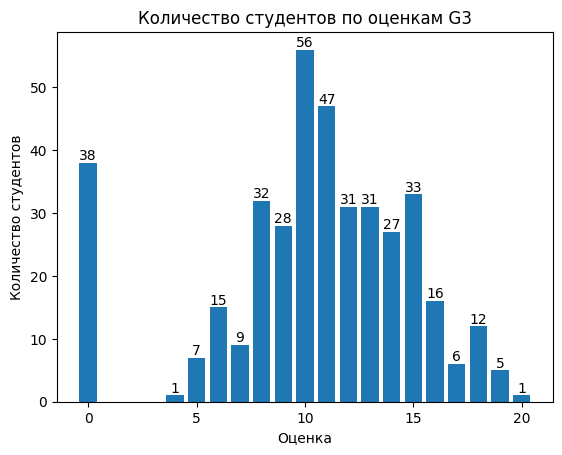

In [ ]:
# Создаем словарь, где ключи - оценки, значения - количество раз, которое каждая оценка встречается
grades_counts = df['G3'].value_counts().sort_index()

# Создаем график
plt.bar(grades_counts.index, grades_counts.values)

# Добавляем надписи с количеством значений над каждым столбцом
for x, y in zip(grades_counts.index, grades_counts.values):
    plt.text(x, y, str(y), ha='center', va='bottom')

# Добавляем заголовок и подписи осей
plt.title('Количество студентов по оценкам G3')
plt.xlabel('Оценка')
plt.ylabel('Количество студентов')

# Показываем график
plt.show()

- Учеников, получившие оценку 4, 20 только один. Мы его уберем т.к при таком дисбалансе классов мы его никогда не найдем, а его присутствие будет мешать для стратификации данных

In [ ]:
# Удаление строк, где значение G3 равно 4 и 20
df = df.drop(df[(df['G3'] == 4) | (df['G3'] == 20)].index)

### Обучение №1.
- В наших данных много категориальных признаков (famsup, nursery, internet и тд). Сначала избавимся от них и обучим нашу модель
- Потом проверим модель, добавив категориальные признаки

In [ ]:
cat_col = df.select_dtypes(include=['object']).columns.tolist()
df_drop_cat = df.drop(columns=cat_col)
print(f'Теперь у нас всего {df_drop_cat.shape[1]} признаков')
df_drop_cat.shape

Теперь у нас всего 16 признаков


(393, 16)

#### Разделим данные на train и test

In [ ]:
# Отделяем целевую метку класса для предсказаний
X = df_drop_cat.drop(columns=['G3'], axis=1)
y = df['G3']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Размерность X_train:", X_train.shape)
print("Размерность X_test:", X_test.shape)
print("Размерность y_train:", y_train.shape)
print("Размерность y_test:", y_test.shape)

Размерность X_train: (275, 15)
Размерность X_test: (118, 15)
Размерность y_train: (275,)
Размерность y_test: (118,)


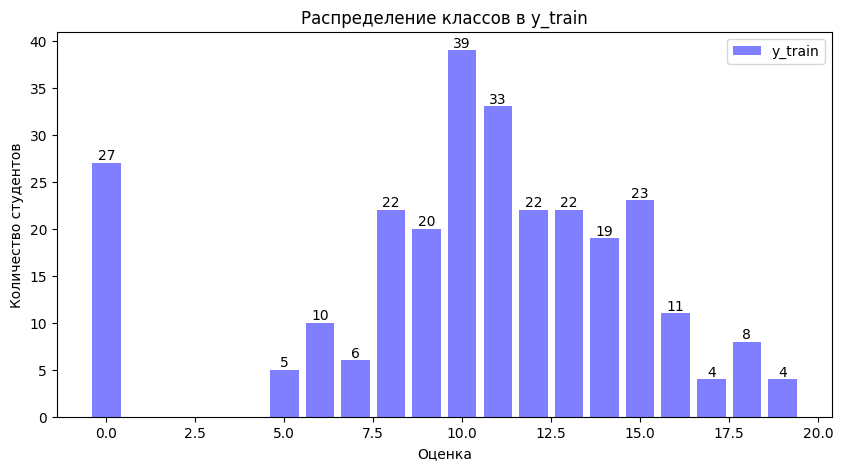

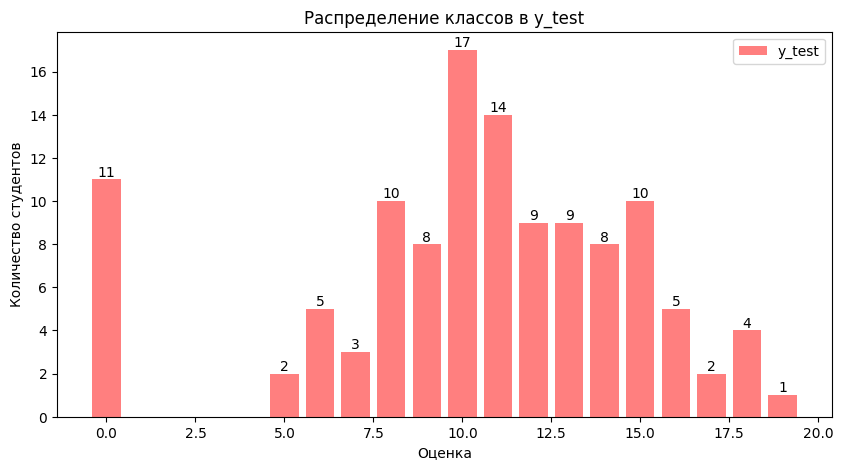

In [ ]:
# График для y_train
plt.figure(figsize=(10, 5))  # Размер графика
grades_counts_train = y_train.value_counts().sort_index()
plt.bar(grades_counts_train.index, grades_counts_train.values, color='blue', alpha=0.5, label='y_train')

# Добавляем надписи с количеством значений над каждым столбцом
for x, y in zip(grades_counts_train.index, grades_counts_train.values):
    plt.text(x, y, str(y), ha='center', va='bottom')

# Заголовок и подписи осей для y_train
plt.title('Распределение классов в y_train')
plt.xlabel('Оценка')
plt.ylabel('Количество студентов')
plt.legend()  # Добавляем легенду

# График для y_test
plt.figure(figsize=(10, 5))  # Размер графика
grades_counts_test = y_test.value_counts().sort_index()
plt.bar(grades_counts_test.index, grades_counts_test.values, color='red', alpha=0.5, label='y_test')

# Добавляем надписи с количеством значений над каждым столбцом
for x, y in zip(grades_counts_test.index, grades_counts_test.values):
    plt.text(x, y, str(y), ha='center', va='bottom')

# Заголовок и подписи осей для y_test
plt.title('Распределение классов в y_test')
plt.xlabel('Оценка')
plt.ylabel('Количество студентов')
plt.legend()  # Добавляем легенду

plt.show()

### Создание модели

In [ ]:
# Наша модель
def create_model(units, optimizer, activation):
    model = Sequential()
    model.add(Dense(units=units, activation=activation, input_shape=(X_train.shape[1],)))
    model.add(Dense(units=units, activation=activation))
    model.add(Dense(units=21, activation='softmax'))
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model
# Комбинация гиперпараметров
param_grid = {
    'model__units': [12,32,64],
    'model__optimizer': ['adam', 'sgd'],
    'model__activation': ['sigmoid', 'tanh', 'relu']
}
# Обертка нашей модели для GridSearchCV
model = KerasClassifier(build_fn=create_model, epochs=10, batch_size=32, verbose=2)
# Объект для поиска лучшей модели
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3)

In [ ]:
# ИНС работают с вещественными значениям, потому преобразуем наши данные в float
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)
y_train = y_train.astype(np.float32)
y_test = y_test.astype(np.float32)

# Ищем параметры лучшей модели
grid_result = grid_search.fit(X_train, y_train)

# Выводим лучшие параметры и оценку
print("Лучшие параметры: ", grid_result.best_params_)
print("Лучшая точность: ", grid_result.best_score_)

# Сохраняем, найденную лучшую модель
best_model = grid_search.best_estimator_
# Делаем предсказание
y_pred = best_model.predict(X_test)

# Вычисляем точность, чувствительность и специфичность.
report = classification_report(y_test, y_pred)
print(report)

Epoch 1/10


6/6 - 1s - 140ms/step - accuracy: 0.0000e+00 - loss: 3.3037
Epoch 2/10
6/6 - 0s - 3ms/step - accuracy: 0.0000e+00 - loss: 3.2561
Epoch 3/10
6/6 - 0s - 3ms/step - accuracy: 0.0000e+00 - loss: 3.2134
Epoch 4/10
6/6 - 0s - 3ms/step - accuracy: 0.0000e+00 - loss: 3.1718
Epoch 5/10
6/6 - 0s - 3ms/step - accuracy: 0.0000e+00 - loss: 3.1355
Epoch 6/10
6/6 - 0s - 2ms/step - accuracy: 0.0000e+00 - loss: 3.0994
Epoch 7/10
6/6 - 0s - 3ms/step - accuracy: 0.0000e+00 - loss: 3.0668
Epoch 8/10
6/6 - 0s - 3ms/step - accuracy: 0.0055 - loss: 3.0368
Epoch 9/10
6/6 - 0s - 3ms/step - accuracy: 0.0109 - loss: 3.0086
Epoch 10/10
6/6 - 0s - 3ms/step - accuracy: 0.0219 - loss: 2.9828
3/3 - 0s - 13ms/step
Epoch 1/10
6/6 - 0s - 65ms/step - accuracy: 0.0546 - loss: 3.1352
Epoch 2/10
6/6 - 0s - 3ms/step - accuracy: 0.0710 - loss: 3.0959
Epoch 3/10
6/6 - 0s - 3ms/step - accuracy: 0.0710 - loss: 3.0612
Epoch 4/10
6/6 - 0s - 3ms/step - accuracy: 0.0765 - loss: 3.0269
Epoch 5/10
6/6 - 0s - 3ms/step - accuracy: 0.076

### Визуализируем матрицу ошибок

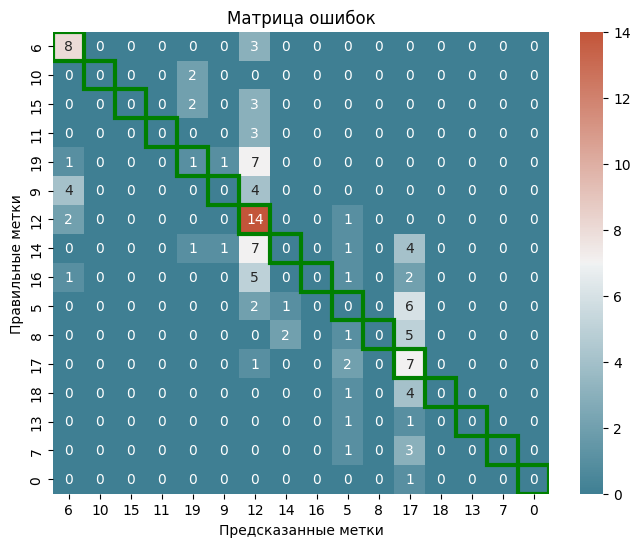

In [ ]:
# Вычисляем индексы правильных и неправильных предсказаний
correct_indices = np.where(y_test == y_pred)[0]
incorrect_indices = np.where(y_test != y_pred)[0]

# Создаем матрицу ошибок
conf_matrix = confusion_matrix(y_test, y_pred)
# Определяем метки
labels = np.array([6, 10, 15, 11, 19, 9, 12, 14, 16, 5, 8, 17, 18, 13, 7, 0])

# Создаем палитру цветов
cmap = sns.diverging_palette(220, 20, as_cmap=True)

# Создаем график
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap=cmap, xticklabels=labels, yticklabels=labels)

# Выделяем диагональ
for i in range(conf_matrix.shape[0]):
    plt.gca().add_patch(plt.Rectangle((i, i), 1, 1, fill=False, edgecolor='green', lw=3))

plt.xlabel('Предсказанные метки')
plt.ylabel('Правильные метки')
plt.title('Матрица ошибок')
plt.show()

##### Наша глупая модель находит хорошо только 6, 12, 17 метки
- Accuracy = 0.25

### Обучение №2
- Теперь мы используем наши категориальные переменные для обучения

In [ ]:
# Создаем объект LabelEncoder
le = LabelEncoder()

# Создаем новый DataFrame для преобразованных данных
X = df.copy()

# Создаем объект LabelEncoder
le = LabelEncoder()

# Преобразуем категориальные переменные
for column in X.columns:
    if X[column].dtype == 'object':  # Проверяем, является ли столбец категориальным
        X[column] = le.fit_transform(X[column])

# Проверяем результат
X

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,0,0,18,1,0,0,4,4,0,4,...,4,3,4,1,1,3,6,5,6,6
1,0,0,17,1,0,1,1,1,0,2,...,5,3,3,1,1,3,4,5,5,6
2,0,0,15,1,1,1,1,1,0,2,...,4,3,2,2,3,3,10,7,8,10
3,0,0,15,1,0,1,4,2,1,3,...,3,2,2,1,1,5,2,15,14,15
4,0,0,16,1,0,1,3,3,2,2,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,1,1,20,1,1,0,2,2,3,3,...,5,5,4,4,5,4,11,9,9,9
391,1,1,17,1,1,1,3,1,3,3,...,2,4,5,3,4,2,3,14,16,16
392,1,1,21,0,0,1,1,1,2,2,...,5,5,3,3,3,3,3,10,8,7
393,1,1,18,0,1,1,3,2,3,2,...,4,4,1,3,4,5,0,11,12,10


In [ ]:
# Отделяем целевую метку класса для предсказаний
X = X.drop(columns=['G3'], axis=1)
y = df['G3']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Размерность X_train:", X_train.shape)
print("Размерность X_test:", X_test.shape)
print("Размерность y_train:", y_train.shape)
print("Размерность y_test:", y_test.shape)

Размерность X_train: (275, 32)
Размерность X_test: (118, 32)
Размерность y_train: (275,)
Размерность y_test: (118,)


In [ ]:
# ИНС работают с вещественными значениям, потому преобразуем наши данные в float
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)
y_train = y_train.astype(np.float32)
y_test = y_test.astype(np.float32)

# Ищем параметры лучшей модели
grid_result = grid_search.fit(X_train, y_train)

# Выводим лучшие параметры и оценку
print("Лучшие параметры: ", grid_result.best_params_)
print("Лучшая точность: ", grid_result.best_score_)

# Сохраняем, найденную лучшую модель
best_model = grid_search.best_estimator_
# Делаем предсказание
y_pred = best_model.predict(X_test)

# Вычисляем точность, чувствительность и специфичность.
report = classification_report(y_test, y_pred)
print(report)

Epoch 1/10


6/6 - 0s - 63ms/step - accuracy: 0.0219 - loss: 3.0742
Epoch 2/10
6/6 - 0s - 2ms/step - accuracy: 0.0492 - loss: 3.0403
Epoch 3/10
6/6 - 0s - 2ms/step - accuracy: 0.0601 - loss: 3.0110
Epoch 4/10
6/6 - 0s - 2ms/step - accuracy: 0.0656 - loss: 2.9819
Epoch 5/10
6/6 - 0s - 2ms/step - accuracy: 0.0874 - loss: 2.9550
Epoch 6/10
6/6 - 0s - 2ms/step - accuracy: 0.0984 - loss: 2.9306
Epoch 7/10
6/6 - 0s - 2ms/step - accuracy: 0.0984 - loss: 2.9070
Epoch 8/10
6/6 - 0s - 3ms/step - accuracy: 0.1038 - loss: 2.8834
Epoch 9/10
6/6 - 0s - 3ms/step - accuracy: 0.1093 - loss: 2.8624
Epoch 10/10
6/6 - 0s - 3ms/step - accuracy: 0.1202 - loss: 2.8407
3/3 - 0s - 11ms/step
Epoch 1/10
6/6 - 0s - 63ms/step - accuracy: 0.0000e+00 - loss: 3.1274
Epoch 2/10
6/6 - 0s - 2ms/step - accuracy: 0.0055 - loss: 3.0933
Epoch 3/10
6/6 - 0s - 3ms/step - accuracy: 0.0710 - loss: 3.0615
Epoch 4/10
6/6 - 0s - 3ms/step - accuracy: 0.0820 - loss: 3.0320
Epoch 5/10
6/6 - 0s - 3ms/step - accuracy: 0.0820 - loss: 3.0054
Epoch 6/

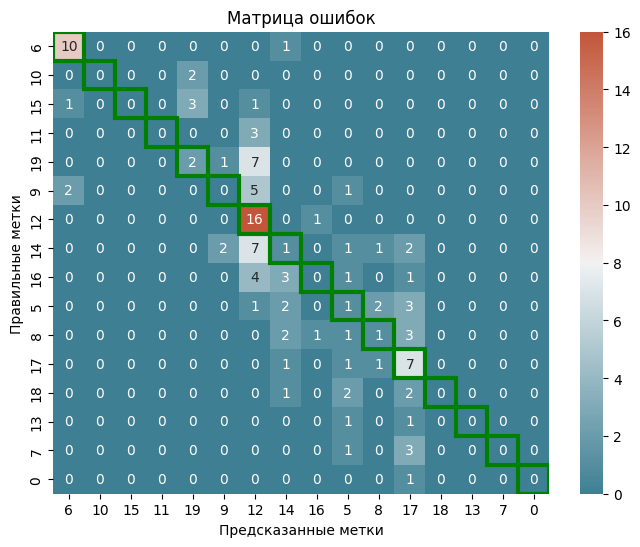

In [ ]:
# Вычисляем индексы правильных и неправильных предсказаний
correct_indices = np.where(y_test == y_pred)[0]
incorrect_indices = np.where(y_test != y_pred)[0]

# Создаем матрицу ошибок
conf_matrix = confusion_matrix(y_test, y_pred)
# Определяем метки
labels = np.array([6, 10, 15, 11, 19, 9, 12, 14, 16, 5, 8, 17, 18, 13, 7, 0])

# Создаем палитру цветов
cmap = sns.diverging_palette(220, 20, as_cmap=True)

# Создаем график
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap=cmap, xticklabels=labels, yticklabels=labels)

# Выделяем диагональ
for i in range(conf_matrix.shape[0]):
    plt.gca().add_patch(plt.Rectangle((i, i), 1, 1, fill=False, edgecolor='green', lw=3))

plt.xlabel('Предсказанные метки')
plt.ylabel('Правильные метки')
plt.title('Матрица ошибок')
plt.show()

##### Наша глупая модель стала работать чуть лучше, используя категориальные переменные
- Accuracy = 0.32

## Результаты и ключевые выводы

### Метрики оценки модели

- **Accuracy:** 0.33

## Обсуждение и Выводы

1. **Эффективность модели:**

   - Модель классификации показала низкую эффективность. Предполгается, что для данной задачи регрессия может подойти куда лучше

2. **Важность признаков:**
   - Дальнейший анализ может быть проведен для изучения важности различных признаков в прогнозировании успеваемости студентов..

## Вывод

В заключение, проект успешно разработал и оценил многоклассовую классификацию  для прогнозирования успеваемости студентов на основе набора данных об успеваемости студентов. Проект улучшил мои навыки предобработки данных, исследовательского анализа данных, обучения моделей и оценки их производительности. В дальнейшем можно провести дополнительные анализы и улучшения модели для дальнейшего повышения точности прогнозирования.